In [4]:
import os

DATASET_PATH = r"C:\Users\Niharika Mirle\Documents\PES\sem5\ML\imgs\train"

print(os.path.exists(DATASET_PATH))

True


In [5]:
classes = sorted(os.listdir(DATASET_PATH))
print(classes)

['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']


In [6]:
for class_name in classes:
    class_path = os.path.join(DATASET_PATH, class_name)
    images = os.listdir(class_path)

    print(class_name, len(images))

c0 2489
c1 2267
c2 2317
c3 2346
c4 2326
c5 2312
c6 2325
c7 2002
c8 1911
c9 2129


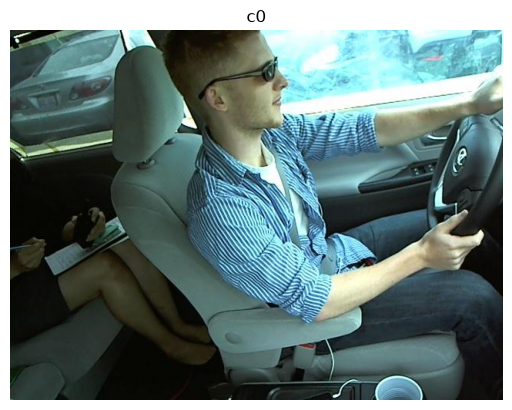

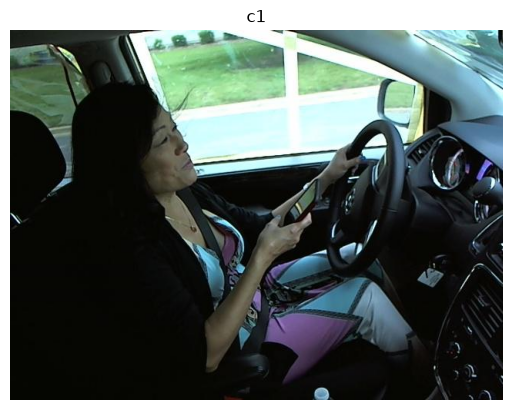

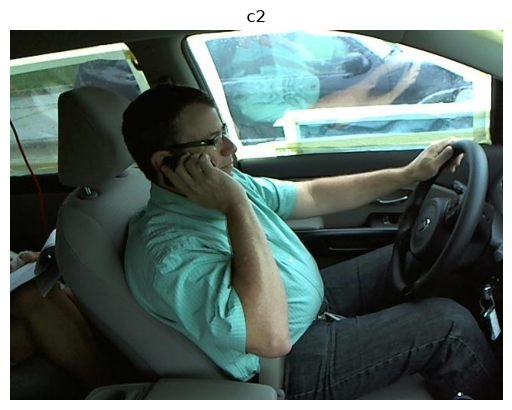

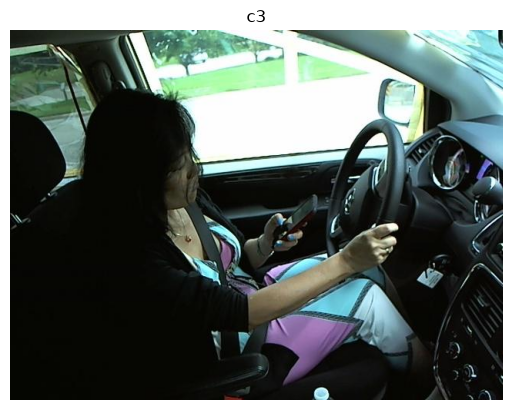

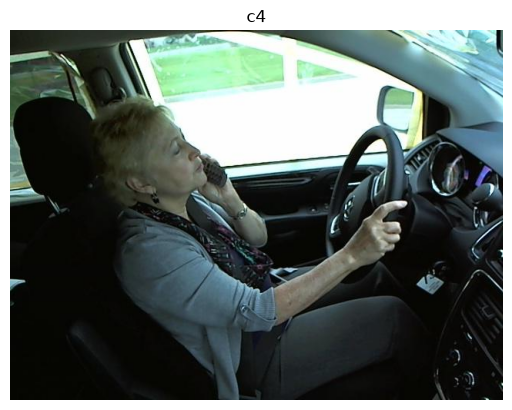

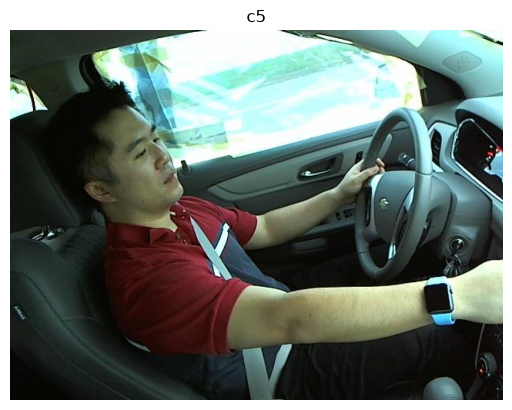

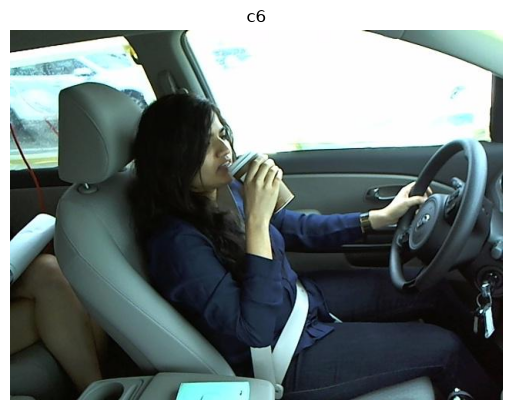

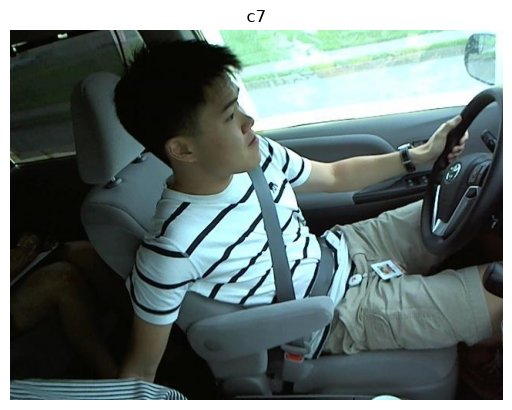

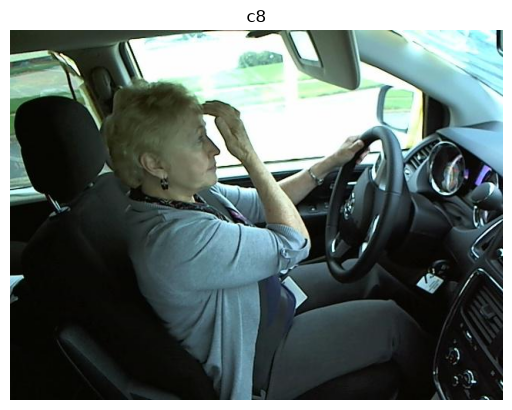

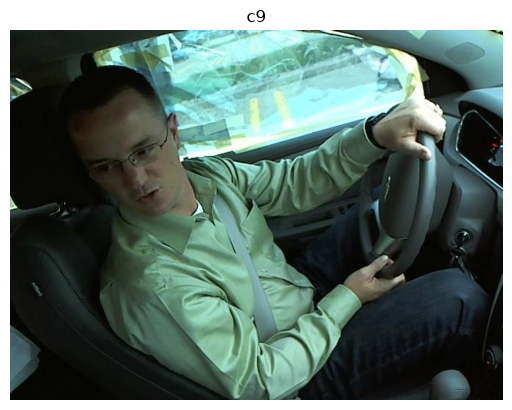

In [7]:
import matplotlib.pyplot as plt
for class_name in classes:
    class_path = os.path.join(DATASET_PATH, class_name)
    
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)
    
    image = plt.imread(image_path)
    
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")
    plt.show()

In [8]:
from PIL import Image
image_path = os.path.join(
    DATASET_PATH,
    classes[0],
    os.listdir(os.path.join(DATASET_PATH, classes[0]))[0]
)

image = Image.open(image_path)

print("Image size:", image.size)
print("Image mode:", image.mode)

Image size: (640, 480)
Image mode: RGB


In [9]:
import tensorflow as tf
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

Found 22424 files belonging to 10 classes.
Using 17940 files for training.


In [10]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

Found 22424 files belonging to 10 classes.
Using 4484 files for validation.


In [13]:
print("Classes:", train_ds.class_names)
print("Number of training batches:", len(train_ds))
print("Number of validation batches:", len(val_ds))
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("First 10 labels:", labels[:10].numpy())

Classes: ['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']
Number of training batches: 561
Number of validation batches: 141
Images shape: (32, 128, 128, 3)
Labels shape: (32,)
First 10 labels: [6 4 5 9 6 3 2 3 7 8]


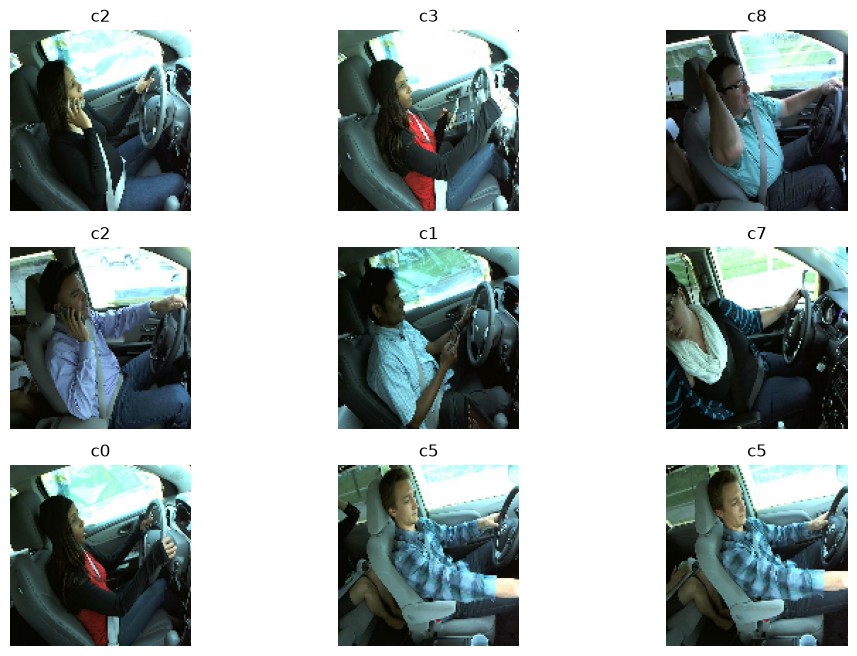

In [14]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")

plt.show()

In [22]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.22.0-rc0
GPU: []


In [23]:
import torch

print("PyTorch version:", torch.__version__)
print("XPU available:", torch.xpu.is_available())

if torch.xpu.is_available():
    device = torch.device("xpu")
    print("Using device:", device)
    print("GPU:", torch.xpu.get_device_name(0))
else:
    device = torch.device("cpu")
    print("Using device:", device)

PyTorch version: 2.14.1+xpu
XPU available: True
Using device: xpu
GPU: Intel(R) Arc(TM) Graphics


In [24]:
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms


In [27]:
import torch.nn as nn
class DistractedDriverCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(128 * 16 * 16, 128),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = DistractedDriverCNN()

print(model)

DistractedDriverCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [30]:
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

DATASET_PATH = r"C:\Users\Niharika Mirle\Documents\PES\sem5\ML\imgs\train"



In [31]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),
    transforms.ColorJitter(contrast=0.1),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [32]:
train_dataset_full = datasets.ImageFolder(
    DATASET_PATH,
    transform=train_transform
)

val_dataset_full = datasets.ImageFolder(
    DATASET_PATH,
    transform=val_transform
)

In [33]:
dataset_size = len(train_dataset_full)

train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

generator = torch.Generator().manual_seed(42)

indices = torch.randperm(
    dataset_size,
    generator=generator
).tolist()

train_indices = indices[:train_size]
val_indices = indices[train_size:]

In [34]:
train_dataset = Subset(
    train_dataset_full,
    train_indices
)

val_dataset = Subset(
    val_dataset_full,
    val_indices
)

In [35]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [ ]:
#testing with one batch
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([32, 3, 128, 128])
Output shape: torch.Size([32, 10])


In [37]:
criterion = nn.CrossEntropyLoss() #loss
#optimizer
optimizer = torch.optim.Adam(  #optimizer
    model.parameters(),
    lr=0.001
)

In [38]:
model.train()

images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

optimizer.zero_grad()

outputs = model(images)

loss = criterion(outputs, labels)

loss.backward()

optimizer.step()

print("Loss:", loss.item())

Loss: 2.3016698360443115


In [39]:
num_epochs = 10
patience = 3

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_val_loss = float("inf")
epochs_without_improvement = 0


for epoch in range(num_epochs):

    # -------------------------
    # TRAINING
    # -------------------------
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Track loss
        running_loss += loss.item() * images.size(0)

        # Track accuracy
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = correct / total

    # -------------------------
    # VALIDATION
    # -------------------------
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total

    # Store results
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.4f}"
    )

    # -------------------------
    # EARLY STOPPING
    # -------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        epochs_without_improvement = 0

        # Save best model
        torch.save(
            model.state_dict(),
            "best_distracted_driver_cnn.pth"
        )

        print("  ✓ Best model saved!")

    else:

        epochs_without_improvement += 1

        print(
            f"  No improvement "
            f"({epochs_without_improvement}/{patience})"
        )

        if epochs_without_improvement >= patience:

            print("Early stopping triggered.")
            break

Epoch [1/10] Train Loss: 1.6626 Train Acc: 0.3859 Val Loss: 0.8115 Val Acc: 0.7674
  ✓ Best model saved!
Epoch [2/10] Train Loss: 0.9783 Train Acc: 0.6448 Val Loss: 0.3925 Val Acc: 0.8970
  ✓ Best model saved!
Epoch [3/10] Train Loss: 0.7172 Train Acc: 0.7445 Val Loss: 0.2556 Val Acc: 0.9284
  ✓ Best model saved!
Epoch [4/10] Train Loss: 0.5488 Train Acc: 0.8060 Val Loss: 0.1517 Val Acc: 0.9592
  ✓ Best model saved!
Epoch [5/10] Train Loss: 0.4484 Train Acc: 0.8453 Val Loss: 0.1302 Val Acc: 0.9645
  ✓ Best model saved!
Epoch [6/10] Train Loss: 0.3875 Train Acc: 0.8659 Val Loss: 0.0931 Val Acc: 0.9726
  ✓ Best model saved!
Epoch [7/10] Train Loss: 0.3320 Train Acc: 0.8854 Val Loss: 0.0747 Val Acc: 0.9802
  ✓ Best model saved!
Epoch [8/10] Train Loss: 0.2974 Train Acc: 0.8978 Val Loss: 0.0666 Val Acc: 0.9817
  ✓ Best model saved!
Epoch [9/10] Train Loss: 0.2646 Train Acc: 0.9074 Val Loss: 0.0574 Val Acc: 0.9855
  ✓ Best model saved!
Epoch [10/10] Train Loss: 0.2540 Train Acc: 0.9111 Val 

In [40]:
print("Epochs completed:", len(train_losses))

print("\nFinal training accuracy:",
      train_accuracies[-1])

print("Final validation accuracy:",
      val_accuracies[-1])

print("\nBest validation accuracy:",
      max(val_accuracies))

Epochs completed: 10

Final training accuracy: 0.9110875745582251
Final validation accuracy: 0.9875139353400223

Best validation accuracy: 0.9875139353400223


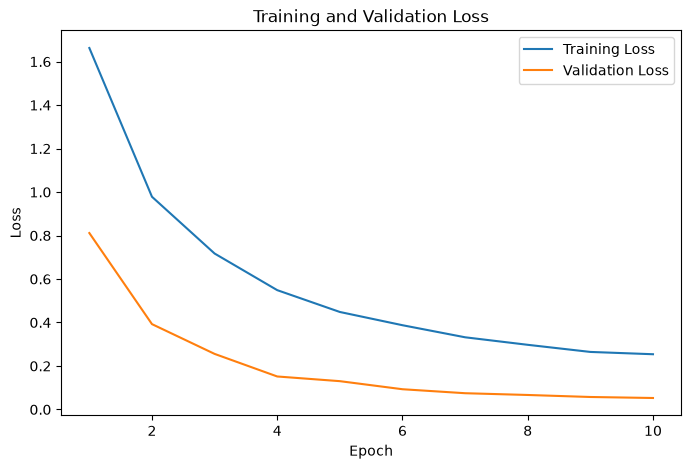

In [41]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label="Training Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

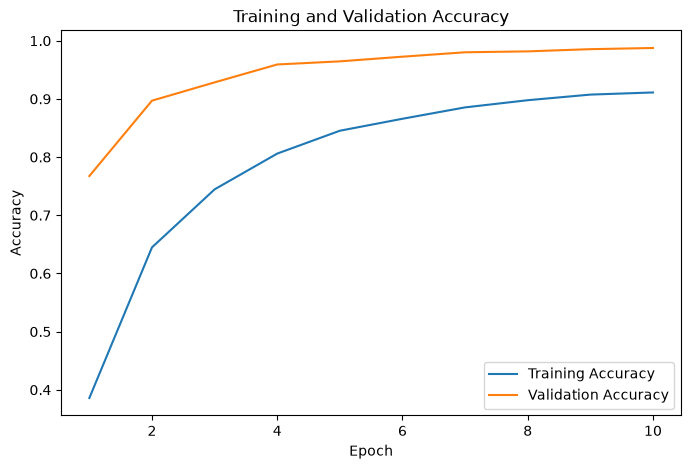

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracies, label="Training Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

In [43]:
print("Total images:", len(train_dataset_full))
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

print("Training indices:", len(train_indices))
print("Validation indices:", len(val_indices))

print(
    "Overlap:",
    len(set(train_indices).intersection(set(val_indices)))
)

Total images: 22424
Training images: 17939
Validation images: 4485
Training indices: 17939
Validation indices: 4485
Overlap: 0


In [44]:
print("Training percentage:",
      len(train_dataset) / len(train_dataset_full) * 100)

print("Validation percentage:",
      len(val_dataset) / len(train_dataset_full) * 100)

Training percentage: 79.99910809846594
Validation percentage: 20.00089190153407


In [45]:
from collections import Counter

train_labels = [
    train_dataset_full.targets[i]
    for i in train_indices
]

val_labels = [
    val_dataset_full.targets[i]
    for i in val_indices
]

print("Training distribution:")
print(Counter(train_labels))

print("\nValidation distribution:")
print(Counter(val_labels))

Training distribution:
Counter({0: 2010, 3: 1873, 5: 1864, 2: 1855, 4: 1849, 6: 1841, 1: 1798, 9: 1700, 7: 1610, 8: 1539})

Validation distribution:
Counter({6: 484, 0: 479, 4: 477, 3: 473, 1: 469, 2: 462, 5: 448, 9: 429, 7: 392, 8: 372})


In [46]:
clean_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

clean_train_full = datasets.ImageFolder(
    DATASET_PATH,
    transform=clean_transform
)

clean_train_dataset = Subset(
    clean_train_full,
    train_indices
)

clean_train_loader = DataLoader(
    clean_train_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

In [47]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in clean_train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

clean_train_accuracy = correct / total

print("Clean training accuracy:", clean_train_accuracy)
print("Validation accuracy:", max(val_accuracies))

Clean training accuracy: 0.9919170522325659
Validation accuracy: 0.9875139353400223


In [48]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

cm = confusion_matrix(all_labels, all_predictions)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[474   0   0   0   0   0   0   0   1   4]
 [  1 468   0   0   0   0   0   0   0   0]
 [  0   0 461   0   0   0   0   0   1   0]
 [  1   0   0 470   1   0   0   0   0   1]
 [  1   1   0   0 474   0   1   0   0   0]
 [  2   0   0   1   0 443   0   0   1   1]
 [  0   1   0   0   0   0 483   0   0   0]
 [  2   0   0   0   0   0   0 385   2   3]
 [  1   2   3   1   1   0   3   0 347  14]
 [  2   0   1   0   0   0   1   0   1 424]]


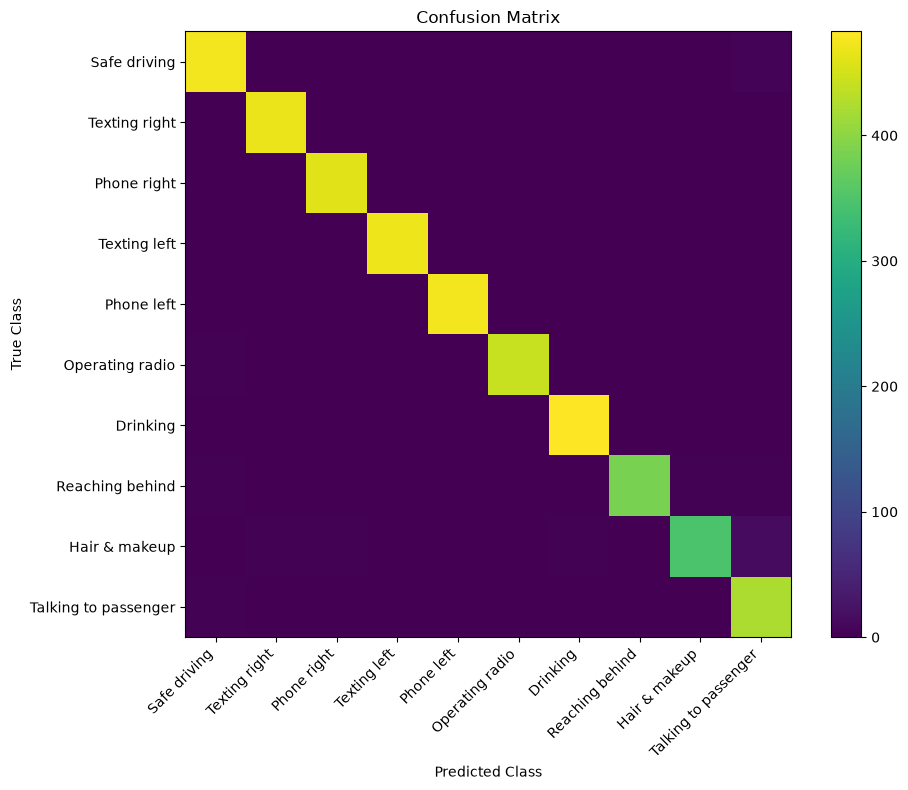

In [49]:
import matplotlib.pyplot as plt

class_names = [
    "Safe driving",
    "Texting right",
    "Phone right",
    "Texting left",
    "Phone left",
    "Operating radio",
    "Drinking",
    "Reaching behind",
    "Hair & makeup",
    "Talking to passenger"
]

plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    range(10),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(10),
    class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

In [50]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)

                      precision    recall  f1-score   support

        Safe driving     0.9793    0.9896    0.9844       479
       Texting right     0.9915    0.9979    0.9947       469
         Phone right     0.9914    0.9978    0.9946       462
        Texting left     0.9958    0.9937    0.9947       473
          Phone left     0.9958    0.9937    0.9948       477
     Operating radio     1.0000    0.9888    0.9944       448
            Drinking     0.9898    0.9979    0.9938       484
     Reaching behind     1.0000    0.9821    0.9910       392
       Hair & makeup     0.9830    0.9328    0.9572       372
Talking to passenger     0.9485    0.9883    0.9680       429

            accuracy                         0.9875      4485
           macro avg     0.9875    0.9863    0.9868      4485
        weighted avg     0.9877    0.9875    0.9875      4485



In [51]:
import os

os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("results/plots", exist_ok=True)
os.makedirs("results/confusion_matrix", exist_ok=True)

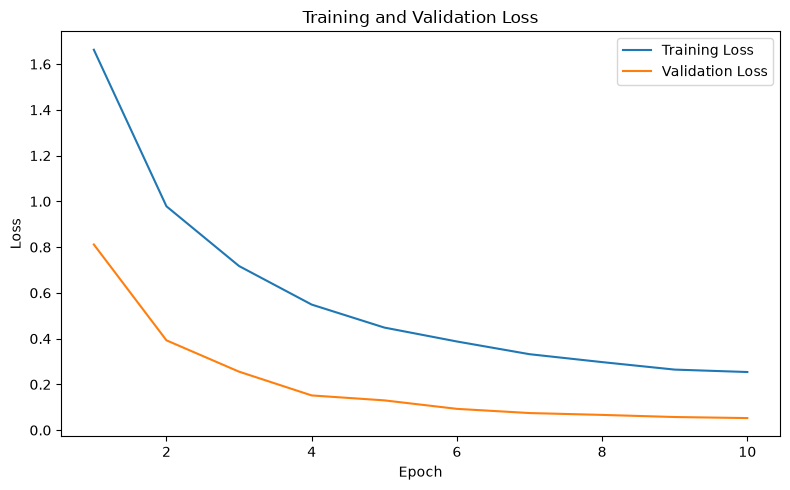

In [52]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    label="Training Loss"
)

plt.plot(
    epochs,
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.tight_layout()

plt.savefig(
    "results/plots/training_validation_loss.png",
    dpi=300
)

plt.show()

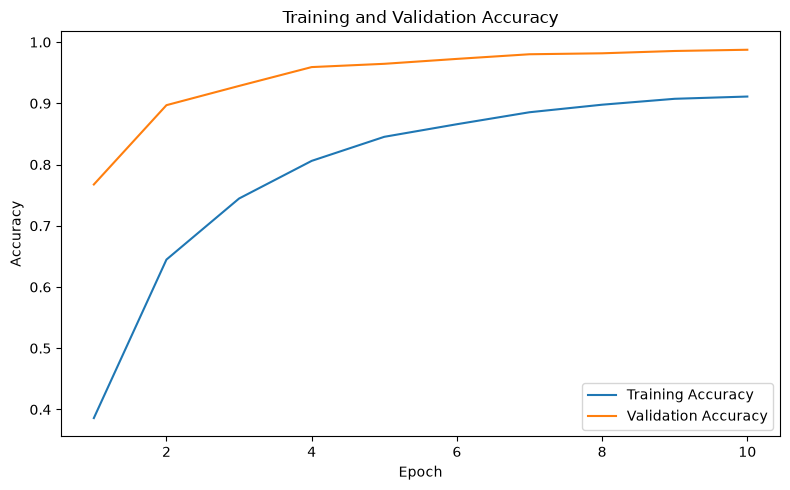

In [53]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()

plt.savefig(
    "results/plots/training_validation_accuracy.png",
    dpi=300
)

plt.show()

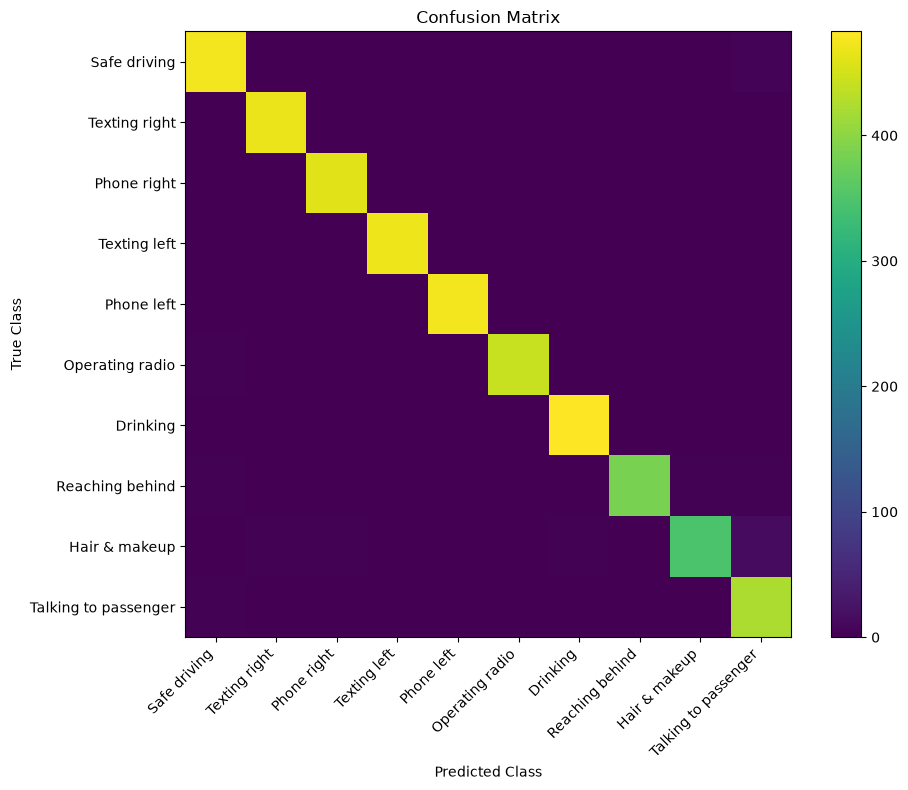

In [54]:
plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    range(10),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(10),
    class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "results/confusion_matrix/confusion_matrix.png",
    dpi=300
)

plt.show()

In [55]:
report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    digits=4
)

with open(
    "results/classification_report.txt",
    "w"
) as f:
    f.write(report)

print("Classification report saved.")

Classification report saved.


In [3]:
import os

print("Current folder:", os.getcwd())
print("\nFiles here:")

for item in os.listdir("."):
    print(item)

Current folder: c:\Users\Niharika Mirle\Documents\PES\sem5\ML\Mini-project\notebooks

Files here:
01_dataset_exploration.ipynb
best_distracted_driver_cnn.pth
models
results


In [6]:
import torch
import torch.nn as nn


class DistractedDriverCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(128 * 16 * 16, 128),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = DistractedDriverCNN()

print("CNN recreated successfully.")


model.load_state_dict(
    torch.load(
        "best_distracted_driver_cnn.pth",
        map_location="cpu"
    )
)

print("Trained weights loaded successfully.")

CNN recreated successfully.
Trained weights loaded successfully.


In [7]:
device = torch.device(
    "xpu" if torch.xpu.is_available() else "cpu"
)

model = model.to(device)

print("Model loaded onto:", device)

Model loaded onto: xpu


In [8]:
import torch
import os

os.makedirs("../models", exist_ok=True)

torch.save(
    model.state_dict(),
    "../models/distracted_driver_cnn.pth"
)

print("Model saved to ../models/distracted_driver_cnn.pth")

Model saved to ../models/distracted_driver_cnn.pth
